In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle

from chronos import Chronos2Pipeline


In [2]:
from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

In [3]:
#with open("/glade/work/stevenxu/FAIR_models/origional_model_extension.pkl", "rb") as f_in:
 #   f1 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top10_model_extension.pkl", "rb") as f_in:
 #   f2 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top20_model_extension.pkl", "rb") as f_in:
 #   f3 = pickle.load(f_in)

In [5]:
f = FAIR(ch4_method="Thornhill2021")
f.define_time(1750, 2500, 1)  # start, end, step

"""
scenarios = [
    "high-extension",
    "high-overshoot",
    "medium-overshoot",
    "medium-extension",
    "low",
    "verylow",
    "verylow-overshoot",
]
"""

scenarios_Rcimp = ['ssp119', 'ssp126', 'ssp245', 'ssp370', 'ssp434', 'ssp460', 'ssp534-over', 'ssp585']
f.define_scenarios(scenarios_Rcimp)
fair_params_1_4_1_file = '/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/calibrated_constrained_parameters_calibration1.4.1.csv'
df_configs = pd.read_csv(fair_params_1_4_1_file, index_col=0)
configs = df_configs.index  # this is used as a label for the "config" axis
f.define_configs(configs)
fair_species_configs_1_4_1_file = '/glade/u/home/stevenxu/FAIRproject/examples/data/calibrated_constrained_ensemble/species_configs_properties_calibration1.4.1.csv'
species_Rcimp, properties = read_properties(filename=fair_species_configs_1_4_1_file)
f.define_species(species_Rcimp, properties)
f.allocate()
"""
f.fill_from_csv(
    emissions_file='examples/data/calibrated_constrained_ensemble/extensions_1750-2500.csv',
    forcing_file='examples/data/calibrated_constrained_ensemble/volcanic_solar.csv',
)
"""

"\nf.fill_from_csv(\n    emissions_file='examples/data/calibrated_constrained_ensemble/extensions_1750-2500.csv',\n    forcing_file='examples/data/calibrated_constrained_ensemble/volcanic_solar.csv',\n)\n"

In [6]:
f.fill_from_rcmip()

f.forcing.sel(specie="Volcanic")
fill(
    f.forcing,
    f.forcing.sel(specie="Volcanic") * df_configs["forcing_scale[Volcanic]"].values.squeeze(),
    specie="Volcanic",
)
fill(
    f.forcing,
    f.forcing.sel(specie="Solar") * df_configs["forcing_scale[Solar]"].values.squeeze(),
    specie="Solar",
)
f.fill_species_configs(fair_species_configs_1_4_1_file)
f.override_defaults(fair_params_1_4_1_file)
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)
initialise(f.ocean_heat_content_change, 0)
f.run()

Running 6728 projections in parallel:   0%|          | 0/750 [00:00<?, ?timesteps/s]

In [ ]:
f

## Chronos Fitting

In [7]:
from chronos import Chronos2Pipeline
pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cpu")


In [8]:
no_emissions_species = []
for specie in f.species:
    da = f.emissions.sel(scenario = f.scenarios[3], specie=specie).mean(dim="config")
    if da.sum() == 0:
        no_emissions_species.append(specie)
no_emissions_species

['Solar',
 'Volcanic',
 'Aerosol-radiation interactions',
 'Aerosol-cloud interactions',
 'Ozone',
 'Light absorbing particles on snow and ice',
 'Stratospheric water vapour',
 'Land use',
 'Equivalent effective stratospheric chlorine']

In [9]:
# Start from xarray
full_da = f.emissions.sel(scenario=f.scenarios[3]).mean(dim='config')

full_df = full_da.to_dataframe('value').reset_index()
full_df = full_df[~full_df['specie'].isin(no_emissions_species)].copy()
full_df['year'] = full_df['timepoints'].astype(int)
full_df = full_df[full_df['year'] <= 2500].copy()

train_df = full_df[full_df['year'] <= 2023].copy()
# future horizon: 2024–2300
future_df = full_df[full_df['year'] > 2023].copy().drop(columns='value')

# tesing data 
test_df = full_df[full_df['year'] > 2023].copy()

prediction_length = future_df['year'].nunique()




In [10]:
# run fitting
pred_df = pipeline.predict_df(
    train_df,
    future_df=future_df,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column='specie',
    timestamp_column='year',  # <--- numeric timestamps
    target='value',
)
pred_df["year"] = pred_df["year"].astype("int64") - 0.5

pred_df

/glade/work/stevenxu/conda-envs/amoc-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


,specie,year,target_name,predictions,0.1,0.5,0.9
0,CO2 FFI,2023.5,value,45.891048,42.891708,45.891048,48.119610
1,CO2 FFI,2024.5,value,46.557613,43.162903,46.557613,49.545952
2,CO2 FFI,2025.5,value,47.310879,42.657940,47.310879,51.272938
3,CO2 FFI,2026.5,value,48.200031,42.984241,48.200031,52.791603
4,CO2 FFI,2027.5,value,49.035011,42.529572,49.035011,55.278889
...,...,...,...,...,...,...,...
24747,HFC-4310mee,2494.5,value,0.000823,-0.004964,0.000823,0.503123
24748,HFC-4310mee,2495.5,value,0.001665,-0.004735,0.001665,0.509665
24749,HFC-4310mee,2496.5,value,0.002252,-0.004294,0.002252,0.488848
24750,HFC-4310mee,2497.5,value,0.000974,-0.003704,0.000974,0.508786


In [11]:
save_path = "/glade/work/stevenxu/FAIR_models/chronos_emission_extension.pkl"
with open(save_path, "wb") as save:
    pickle.dump(pred_df, save)


In [ ]:
history_df = train_df.copy()
history_df["year"] = history_df["year"] + 0.5
history_df

,timepoints,specie,scenario,value,year
0,1750.5,CO2 FFI,ssp370,0.009506,1750.5
1,1750.5,CO2 AFOLU,ssp370,0.297465,1750.5
2,1750.5,CO2,ssp370,0.306970,1750.5
3,1750.5,CH4,ssp370,19.019783,1750.5
4,1750.5,N2O,ssp370,0.086022,1750.5
...,...,...,...,...,...
16700,2023.5,HFC-236fa,ssp370,0.461710,2023.5
16701,2023.5,HFC-245fa,ssp370,20.795721,2023.5
16702,2023.5,HFC-32,ssp370,4.812130,2023.5
16703,2023.5,HFC-365mfc,ssp370,5.138875,2023.5


: 

In [ ]:
def plot_fair_chronos_combined(specie, showPlot=True, savePlot=False, save_path='/glade/u/home/stevenxu/FAIRproject/graph_outputs/Chronos_plots/emissions'):

    scenario_names = list(f.scenarios)     # all FAIR scenarios

    # -------------------------
    # Chronos predictions
    # -------------------------
    spec_pred = (
        pred_df[pred_df["specie"] == specie]
        .sort_values("year")
    )

    x_pred   = spec_pred["year"]
    y_pred   = spec_pred["predictions"]
    low_pred = spec_pred["0.1"]
    high_pred= spec_pred["0.9"]

    # --------------------------
    #   HISTORY PART (FAIR)
    # --------------------------
    spec_hist = history_df[history_df["specie"] == specie].copy()
    spec_hist = spec_hist.sort_values("year")

    x_hist = spec_hist["year"]       # e.g., 1750.5, 1751.5 ...
    y_hist = spec_hist["value"]

    # -------------------------
    # FAIR part
    # -------------------------
    fair_lines = {}

    for scen in scenario_names:
        da = (
            f1.emissions
            .sel(scenario=scen, specie=specie, timepoints =slice(2023.5, 2500.5))
            .mean(dim="config")              # mean over config
        )
        df = da.to_dataframe("fair_value").reset_index()
        df["year"] = df["timepoints"]         # FAIR uses mid-year floats

        fair_lines[scen] = df.sort_values("year")

    # -------------------------
    # PLOT everything
    # -------------------------
    plt.figure(figsize=(8, 5))


    # History curve
    plt.plot(x_hist, y_hist, label="history", color="Black", linewidth=2)

    # Plot ALL FAIR scenarios
    for scen, df in fair_lines.items():
        plt.plot(
            df["year"],
            df["fair_value"],
            linewidth=1.0,
            label=f"FAIR {scen}"
        )

    # Chronos forecast
    plt.plot(
        x_pred,
        y_pred,
        color="xkcd:azure",
        linewidth=2.5,
        label="Chronos forecast"
    )

    # Prediction interval (darker as requested)
    plt.fill_between(
        x_pred,
        low_pred,
        high_pred,
        alpha=0.2,
        color="xkcd:azure",
        label="0.1–0.9 interval"
    )

    plt.axvline(x=2023, color="black", linestyle="--", linewidth=1.2, alpha=0.5)

    plt.xlabel("Year")
    plt.ylabel("Value")
    plt.title(f"Chronos emissions Forecast: {specie}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if showPlot:
        plt.show()

    if savePlot:
        save_dir = save_path + f'/{specie}_Chronos_emissions_Forecast.png'
        plt.savefig(save_dir)

    plt.close()


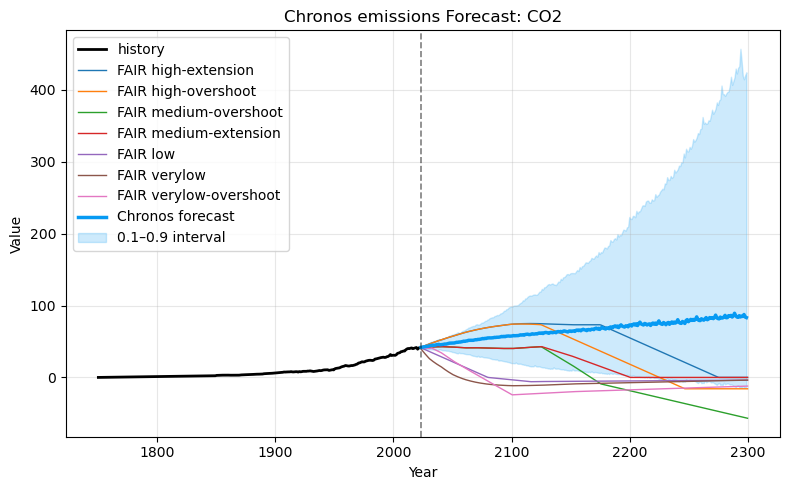

In [ ]:
plot_fair_chronos_combined('CO2', showPlot=True, savePlot=False, save_path='/glade/u/home/stevenxu/FAIRproject/graph_outputs/Chronos_plots/emissions')

In [ ]:
for specie in pred_df['specie'].unique():
    plot_fair_chronos_combined(specie, showPlot=False, savePlot=True, save_path='/glade/u/home/stevenxu/FAIRproject/graph_outputs/Chronos_plots/emissions')